<a href="https://colab.research.google.com/github/Snake-AID/SnakeAid.ComputerVision/blob/main/SnakeAId_MaskingVerify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLOv12 Masking Dataset Audit (5000)

Dataset có 3 split:

* `train/images`, `train/labels`
* `valid/images`, `valid/labels`
* `test/images`, `test/labels`

Mục tiêu audit:

1. **Pairing**: ảnh nào có label tương ứng? label nào thiếu ảnh? ảnh nào thiếu label?
2. **Validate masking**: label có đúng format polygon YOLO segmentation không? polygon có “vẽ được” không?
3. **Preview**: chỉ xuất ảnh `warn/error` để bạn check nhanh
4. **Report**: xuất bảng CSV và hiển thị trong Colab

## Mount Google Drive

In [51]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Config paths & runtime parameters

* `DATASET_ROOT`: thư mục dataset
* `SPLITS`: `["train","valid","test"]`
* `OUT_DIR = <root>/_audit`
* `PREVIEW_DIR = <root>/_audit/preview`
* `MAX_WORKERS`: số luồng (thread)
* `ALPHA`: độ trong suốt khi overlay mask lên ảnh

Ngoài ra có 2 tham số quan trọng cho “mask rắn”:

* `KEEP_TINY_POLYGONS`
* `TINY_AREA_THRESH`

Ý nghĩa:

* Có những mask rất mảnh/nhỏ (rắn xa) → diện tích polygon sau khi scale ra pixel có thể cực nhỏ.
* Nếu bạn “loại polygon nhỏ” thì sẽ dẫn tới `no_valid_polygon` và preview không vẽ gì.
* Nên với rắn: thường **giữ polygon nhỏ** để vẫn vẽ được.

In [52]:
import os

# === EDIT THIS ===
DATASET_ROOT = "/content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking"

SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = [".jpg", ".png", ".jpeg"]

OUT_DIR = os.path.join(DATASET_ROOT, "_audit")
PREVIEW_DIR = os.path.join(OUT_DIR, "preview")

# Multi-thread tuning (Drive I/O bound)
MAX_WORKERS = 12   # recommend: 8-16

# Mask overlay transparency
ALPHA = 0.5

# IMPORTANT for snake masks:
# If True: keep tiny polygons (do not discard by area)
KEEP_TINY_POLYGONS = True
TINY_AREA_THRESH = 1.0

os.makedirs(PREVIEW_DIR, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT)
print("OUT_DIR     :", OUT_DIR)
print("PREVIEW_DIR :", PREVIEW_DIR)
print("MAX_WORKERS :", MAX_WORKERS)
print("KEEP_TINY_POLYGONS:", KEEP_TINY_POLYGONS)

DATASET_ROOT: /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking
OUT_DIR     : /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_audit
PREVIEW_DIR : /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_audit/preview
MAX_WORKERS : 12
KEEP_TINY_POLYGONS: True


## Core logic (pairing, parsing, overlay)

In [53]:
import cv2
import numpy as np

### 1) `find_image(image_dir, stem)`

Nhiệm vụ: tìm file ảnh tương ứng với `stem` theo các đuôi `.jpg/.png/.jpeg`.

Ví dụ:

* label: `abc.txt` → stem = `abc`
* tìm `images/abc.jpg` hoặc `images/abc.png`...

➡️ Đảm bảo pairing đúng kể cả khi ảnh không đồng nhất extension.

In [54]:
def find_image(image_dir, stem):
    for ext in IMAGE_EXTS:
        p = os.path.join(image_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None

### 2) `parse_yolo_seg_line(line)`

Nhiệm vụ: validate *format dòng label*.

YOLO segmentation line dạng:

```
<class_id> x1 y1 x2 y2 ... xn yn
```

Check:

* phải có ít nhất 3 điểm ⇒ tối thiểu 6 số tọa độ + 1 class ⇒ `len(parts) >= 7`
* coords phải parse được float
* số coords phải chẵn
* coords phải nằm trong [0..1] (normalized)

➡️ Nếu fail, ghi lỗi như:

* `non_numeric`
* `odd_coord_count`
* `coord_out_of_range`
* `too_few_points`

In [55]:
def parse_yolo_seg_line(line):
    """
    Expected YOLO segmentation line:
    <class_id> x1 y1 x2 y2 ... xn yn   (normalized 0..1)
    """
    parts = line.strip().split()
    if len(parts) < 7:
        return None, None  # not enough points for polygon (needs >= 3 points)

    cls = parts[0]
    try:
        coords = list(map(float, parts[1:]))
    except:
        return cls, "non_numeric"

    if len(coords) % 2 != 0:
        return cls, "odd_coord_count"

    arr = np.array(coords, dtype=np.float32)
    if np.any(arr < 0) or np.any(arr > 1):
        return cls, "coord_out_of_range"

    if len(coords) < 6:
        return cls, "too_few_points"

    return cls, None

### 3) `load_polygons(label_path, w, h)`

Nhiệm vụ: đọc **toàn bộ file label**, biến từng dòng hợp lệ thành **polygon pixel**.

Flow bên trong:

1. đọc từng dòng `line`
2. validate bằng `parse_yolo_seg_line`
3. nếu OK → lấy coords normalized → scale sang pixel:

   * `x_pixel = int(x_norm * w)`
   * `y_pixel = int(y_norm * h)`
4. tạo `poly = np.array([[x,y],...], int32)`
5. tính `area = cv2.contourArea(poly)`

#### Chỗ quan trọng với bạn: tiny polygons

* Nếu `area <= TINY_AREA_THRESH`:

  * nếu `KEEP_TINY_POLYGONS=True` → vẫn giữ polygon để vẽ, nhưng log `tiny_area=...`
  * nếu `False` → loại polygon, log `zero_area`

➡️ Kết quả trả về:

* `polygons`: list các polygon hợp lệ (để overlay)
* `issues`: list các lỗi theo dòng

In [56]:
def load_polygons(label_path, w, h):
    """
    Returns: (polygons, issues)
    polygons: list[np.ndarray Nx2 int32]
    issues  : list[str]
    """
    polygons, issues = [], []
    with open(label_path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f, start=1):
            if not line.strip():
                continue

            cls, err = parse_yolo_seg_line(line)
            if err:
                issues.append(f"line{idx}:{err}")
                continue

            coords = list(map(float, line.strip().split()[1:]))
            pts = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i + 1] * h)
                pts.append([x, y])

            poly = np.array(pts, dtype=np.int32)

            area = cv2.contourArea(poly)
            if area <= TINY_AREA_THRESH:
                # For snake masks, tiny polygons can be real.
                if KEEP_TINY_POLYGONS:
                    issues.append(f"line{idx}:tiny_area={area:.3f}")
                    polygons.append(poly)
                else:
                    issues.append(f"line{idx}:zero_area")
                continue

            polygons.append(poly)

    return polygons, issues

### 4) `overlay_mask(img_bgr, polygons)`

Nhiệm vụ: vẽ mask lên ảnh.

* tạo `overlay = img.copy()`
* `cv2.fillPoly(overlay, poly, green)`
* trộn với ảnh gốc theo alpha:

  * `out = overlay*alpha + img*(1-alpha)`

➡️ Đây là preview bạn xem trực quan.

In [57]:
def overlay_mask(img_bgr, polygons, alpha=ALPHA):
    overlay = img_bgr.copy()
    for poly in polygons:
        cv2.fillPoly(overlay, [poly], (0, 255, 0))
    return cv2.addWeighted(overlay, alpha, img_bgr, 1 - alpha, 0)

### 5) `process_one(split, stem, img_dir, lbl_dir)` (hàm “unit of work”)

Đây là trung tâm của cả pipeline. Nó xử lý **1 sample** theo stem.

Nó trả về:

* `row` (1 dòng report)
* `exported` (0/1: có xuất preview hay không)

#### A) Pairing logic (ảnh/label)

* `img_path = find_image(...)`
* `lbl_path = labels/<stem>.txt`

Check 2 lỗi pairing:

1. **label có nhưng thiếu ảnh**

* `img_path is None` và `label tồn tại`
* status = `error`, issues += `missing_image`

2. **ảnh có nhưng thiếu label**

* `img_path != None` và `label không tồn tại`
* status = `error`, issues += `missing_label`

#### B) Nếu có cả ảnh và label

* đọc ảnh bằng `cv2.imread`

  * fail → `unreadable_image` (error)
* lấy `w,h`
* parse polygon bằng `load_polygons`
* `poly_count = len(polygons)`

Nếu `poly_count == 0` → status chuyển thành `warn`, issues += `no_valid_polygon`

Nếu có `line_issues` → status ít nhất là `warn`

#### C) Export preview

Chỉ xuất preview nếu không OK:

* nếu `status in ["warn","error"]`:

  * nếu `poly_count > 0` → overlay và save
  * nếu `poly_count == 0` → save ảnh gốc

➡️ Vì vậy: “có ảnh preview nhưng không thấy polygon” = thường do `poly_count == 0`

In [58]:
def process_one(split, stem, img_dir, lbl_dir):
    """
    One unit of work:
    - pairing image & label
    - read img, parse polygon
    - export preview for warn/error
    - return row dict + exported(0/1)
    """
    img_path = find_image(img_dir, stem)
    lbl_path = os.path.join(lbl_dir, stem + ".txt")

    status = "ok"
    issues = []
    w = h = None
    poly_count = 0
    exported = 0

    if img_path is None and os.path.exists(lbl_path):
        status = "error"
        issues.append("missing_image")

    if img_path is not None and not os.path.exists(lbl_path):
        status = "error"
        issues.append("missing_label")

    if img_path is not None and os.path.exists(lbl_path):
        img = cv2.imread(img_path)
        if img is None:
            status = "error"
            issues.append("unreadable_image")
        else:
            h, w = img.shape[:2]
            polygons, line_issues = load_polygons(lbl_path, w, h)
            poly_count = len(polygons)

            if poly_count == 0:
                status = "warn" if status == "ok" else status
                issues.append("no_valid_polygon")

            if line_issues:
                status = "warn" if status == "ok" else status
                issues.extend(line_issues)

            # Export preview only if not OK
            if status in ["warn", "error"]:
                out = overlay_mask(img, polygons) if poly_count > 0 else img
                out_name = f"{split}__{stem}.jpg"
                cv2.imwrite(os.path.join(PREVIEW_DIR, out_name), out)
                exported = 1

    row = {
        "split": split,
        "stem": stem,
        "status": status,
        "issues": "|".join(issues),
        "image_path": img_path or "",
        "label_path": lbl_path if os.path.exists(lbl_path) else "",
        "w": w, "h": h,
        "polygon_count": poly_count
    }
    return row, exported

## Run audit (multi-threaded)

Với mỗi `split`:

1. lấy tất cả stem từ label: `label_stems`
2. lấy tất cả stem từ image: `image_stems`
3. union lại: `all_stems = label_stems ∪ image_stems`

➡️ Union để bắt đủ cả 2 trường hợp:

* có label mà thiếu ảnh
* có ảnh mà thiếu label

Sau đó chạy đa luồng:

* mỗi stem là 1 job → `process_one(...)`
* dùng `ThreadPoolExecutor`
* gom kết quả vào list `rows`

**Vì sao Thread hợp lý?**

* Drive đọc/ghi file là I/O bound
* Thread giúp “đợi I/O song song” → nhanh hơn

In [59]:
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

rows = []
exported_total = 0

for split in SPLITS:
    print(f"\n=== AUDIT SPLIT: {split} ===")

    img_dir = os.path.join(DATASET_ROOT, split, "images")
    lbl_dir = os.path.join(DATASET_ROOT, split, "labels")

    label_files = [f for f in os.listdir(lbl_dir) if f.endswith(".txt")]
    label_stems = set(os.path.splitext(f)[0] for f in label_files)

    image_files = os.listdir(img_dir)
    image_stems = set(
        os.path.splitext(f)[0]
        for f in image_files
        if os.path.splitext(f)[1].lower() in IMAGE_EXTS
    )

    all_stems = sorted(label_stems.union(image_stems))

    futures = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        for stem in all_stems:
            futures.append(ex.submit(process_one, split, stem, img_dir, lbl_dir))

        for fut in tqdm(as_completed(futures), total=len(futures), desc=f"{split} (MT)", unit="file"):
            row, exported = fut.result()
            rows.append(row)
            exported_total += exported

df = pd.DataFrame(rows)
print("\n✅ Audit finished.")
print("Total rows:", len(df))
print("Preview exported:", exported_total)


=== AUDIT SPLIT: train ===


train (MT): 100%|██████████| 4563/4563 [01:35<00:00, 47.65file/s] 



=== AUDIT SPLIT: valid ===


valid (MT): 100%|██████████| 197/197 [00:01<00:00, 111.58file/s]



=== AUDIT SPLIT: test ===


test (MT): 100%|██████████| 197/197 [00:02<00:00, 84.42file/s]


✅ Audit finished.
Total rows: 4957
Preview exported: 11


## Export report + summary CSV

Sau khi có `df = DataFrame(rows)`:

* `audit_report.csv`: full list tất cả sample

  * split, stem, status, issues, paths, w/h, polygon_count
* `summary.csv`: thống kê số lượng ok/warn/error theo split

In [60]:
import os

os.makedirs(OUT_DIR, exist_ok=True)

report_path = os.path.join(OUT_DIR, "audit_report.csv")
summary_path = os.path.join(OUT_DIR, "summary.csv")

df.to_csv(report_path, index=False, encoding="utf-8-sig")

summary = df.groupby(["split", "status"]).size().reset_index(name="count")
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("✅ Saved:")
print(" - report :", report_path)
print(" - summary:", summary_path)
print(" - preview:", PREVIEW_DIR)

✅ Saved:
 - report : /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_audit/audit_report.csv
 - summary: /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_audit/summary.csv
 - preview: /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_audit/preview


## Display tables in Colab (summary + problematic samples)

* `display(summary)` để nhìn tổng quan
* lọc `no_poly`:

  ```python
  df[(status in warn/error) & (polygon_count == 0)]
  ```

  → đúng cái bạn đã check “Count no polygon previews: 11”
* lọc `missing_*` để xem pairing lỗi hay không

In [61]:
import pandas as pd

# Summary table
display(summary)

# Show "no polygon preview" cases
no_poly = df[(df["status"].isin(["warn","error"])) & (df["polygon_count"] == 0)].copy()
print("Count no polygon previews:", len(no_poly))
display(no_poly[["split","stem","status","issues","image_path","label_path"]].head(30))

# Optional: show missing cases
missing = df[df["issues"].str.contains("missing_", na=False)]
print("Count missing pairs:", len(missing))
display(missing[["split","stem","status","issues","image_path","label_path"]].head(30))

,split,status,count
0,test,ok,194
1,test,warn,3
2,train,ok,4555
3,train,warn,8
4,valid,ok,197


Count no polygon previews: 10


,split,stem,status,issues,image_path,label_path
100,train,cap_nia_bac36_jpeg.rf.cbf3dfaf4140d8486f4ec02c...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
150,train,cap_nia_bac55_jpeg.rf.e2e5a3df3b02c139bf254c0b...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
626,train,cap_nong49_jpeg.rf.e72ee5906dec20a78b2916e224f...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
631,train,cap_nong51_jpeg.rf.98c9f0f56af1620a55fb7b707a7...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
640,train,cap_nong51_jpeg.rf.b6f2d481ea03b7df2a66d15fbf3...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
1205,train,ho_mang_chua109_jpeg.rf.8614c04d7ff1ee1252997e...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
3742,train,rao_trau14_jpeg.rf.e67d33c3e42251f3bf662f6e310...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
4837,test,hoc_tro16_jpeg.rf.613d3d4926d35640137794db9146...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
4849,test,hoc_tro85_jpg.rf.b0a702322ccd72665012e0a2e46e6f38,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
4863,test,khiem_vach95_jpeg.rf.c0dc56a69fe51e846bcf646e0...,warn,no_valid_polygon,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...


Count missing pairs: 0


,split,stem,status,issues,image_path,label_path


# Semantic QC for YOLOv12 Segmentation (Snake Mask Integrity)

## Goal:
- Detect masks that are "semantically truncated" (e.g., only head/tail)
- WITHOUT reviewing all 5000 images

## Approach:
- Convert polygon -> binary mask
- Compute shape-based metrics:
  1. Skeleton length (normalized)
  1. CA elongation ratio
  1. PCA coverage ratio along main axis
- Rank suspicious samples + export Top-K previews

## Mount Google Drive

In [42]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install dependencies
* `opencv-python` để vẽ mask/preview
* `scikit-image` để skeletonize (xương hoá mask)
* `pandas`, `tqdm` để làm report + progress

In [43]:
!pip -q install opencv-python scikit-image pandas tqdm

## Configuration (dataset path + QC settings)
* Sửa `DATASET_ROOT` đúng đường dẫn của bạn
* `TOPK_PREVIEW`: số lượng ảnh nghi vấn cần export để bạn duyệt nhanh (không phải 5000)

In [44]:
import os

# ===== EDIT THIS PATH =====
DATASET_ROOT = "/content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking"

SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = [".jpg", ".png", ".jpeg"]

# Output folders
OUT_DIR = os.path.join(DATASET_ROOT, "_semantic_qc")
PREVIEW_DIR = os.path.join(OUT_DIR, "preview_topk")
os.makedirs(PREVIEW_DIR, exist_ok=True)

# How many suspicious samples to export as previews (recommend 200~500)
TOPK_PREVIEW = 300

# Speed tuning (Drive is IO bound)
MAX_WORKERS = 12  # 8~16 recommended

print("DATASET_ROOT:", DATASET_ROOT)
print("OUT_DIR     :", OUT_DIR)
print("PREVIEW_DIR :", PREVIEW_DIR)
print("TOPK_PREVIEW:", TOPK_PREVIEW)
print("MAX_WORKERS :", MAX_WORKERS)

DATASET_ROOT: /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking
OUT_DIR     : /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_semantic_qc
PREVIEW_DIR : /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_semantic_qc/preview_topk
TOPK_PREVIEW: 300
MAX_WORKERS : 12


## Core utilities (pairing + polygon parsing)
* Pairing image ↔ label theo stem (tên file)
* Parse label YOLO segmentation: `<cls> x1 y1 x2 y2 ...` (normalized 0..1)

In [45]:
import numpy as np

def find_image(image_dir, stem, exts=IMAGE_EXTS):
    for ext in exts:
        p = os.path.join(image_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None

def parse_yolo_polygon_lines(label_path):
    """
    Read YOLO segmentation txt.
    Returns: list of (class_id:int, coords:list[float]) where coords are normalized [0..1]
    Validates basic syntax only; semantic QC happens later.
    """
    items = []
    if not os.path.exists(label_path):
        return items, ["missing_label"]

    issues = []
    with open(label_path, "r", encoding="utf-8") as f:
        for li, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 7:
                issues.append(f"line{li}:too_few_points")
                continue
            try:
                cls = int(float(parts[0]))
                coords = list(map(float, parts[1:]))
            except:
                issues.append(f"line{li}:non_numeric")
                continue
            if len(coords) % 2 != 0:
                issues.append(f"line{li}:odd_coord_count")
                continue
            arr = np.array(coords, dtype=np.float32)
            if np.any(arr < 0) or np.any(arr > 1):
                issues.append(f"line{li}:coord_out_of_range")
                continue
            items.append((cls, coords))
    return items, issues

## Mask building + semantic metrics (Skeleton + PCA)
Đây là phần “QC ngữ nghĩa” để bắt trường hợp **Roboflow giữ 1 mảnh → chỉ còn đầu/đuôi**.

Metrics chính:

1. `skeleton_len_norm`: xương hoá mask và đo độ dài (chuẩn hoá theo đường chéo ảnh)
2. `pca_elongation`: độ “dài” theo PCA (mẩu đầu thường kém elongated hơn)
3. `pca_coverage`: mức trải dài theo trục chính (mẩu nhỏ sẽ coverage thấp)

In [46]:
import cv2
from skimage.morphology import skeletonize

def polygons_to_mask(items, w, h):
    """
    items: list of (cls, coords normalized)
    returns: binary mask uint8 (0/1)
    """
    mask = np.zeros((h, w), dtype=np.uint8)
    for cls, coords in items:
        pts = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)
            pts.append([x, y])
        poly = np.array(pts, dtype=np.int32)
        if len(poly) >= 3:
            cv2.fillPoly(mask, [poly], 1)
    return mask

def compute_pca_metrics(mask):
    """
    PCA on mask pixels.
    Returns:
      elongation_ratio: sqrt(lambda1/lambda2) (>=1)
      coverage_ratio  : range along main axis / diagonal
      center_xy       : mean point
      axis_dir        : unit vector of main axis (dx,dy)
    """
    ys, xs = np.where(mask > 0)
    if len(xs) < 20:
        return None  # too few pixels

    pts = np.stack([xs, ys], axis=1).astype(np.float32)
    mean = pts.mean(axis=0)
    centered = pts - mean

    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)  # ascending
    # take largest eigenvalue/vector as main axis
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    lam1 = max(eigvals[0], 1e-9)
    lam2 = max(eigvals[1], 1e-9)
    elongation = float(np.sqrt(lam1 / lam2))

    main_axis = eigvecs[:, 0]  # (dx,dy) in x,y
    # projection onto main axis
    proj = centered @ main_axis
    proj_range = float(proj.max() - proj.min())

    return elongation, proj_range, mean, main_axis

def compute_skeleton_length(mask):
    """
    Skeletonize and approximate length by counting skeleton pixels.
    (Good enough for ranking suspicious cases.)
    """
    skel = skeletonize(mask.astype(bool))
    skel_len = int(skel.sum())
    return skel.astype(np.uint8), skel_len

def semantic_qc(mask):
    """
    Return dict metrics; None if mask too small.
    """
    h, w = mask.shape[:2]
    area = int(mask.sum())
    if area < 20:
        return None

    diag = float(np.hypot(w, h))

    skel, skel_len = compute_skeleton_length(mask)
    skel_len_norm = skel_len / max(diag, 1e-9)

    pca = compute_pca_metrics(mask)
    if pca is None:
        return None
    elongation, proj_range, center, axis = pca
    coverage = proj_range / max(diag, 1e-9)

    return {
        "mask_area": area,
        "mask_area_frac": area / float(w*h),
        "skeleton_len": skel_len,
        "skeleton_len_norm": skel_len_norm,
        "pca_elongation": elongation,
        "pca_coverage": coverage,
        "center_x": float(center[0]),
        "center_y": float(center[1]),
        "axis_dx": float(axis[0]),
        "axis_dy": float(axis[1]),
    }, skel


## Run QC over full dataset (multi-threaded) and build report table

Cell này chạy trên **100% ảnh**:

* Pair image/label
* Tạo mask
* Tính semantic metrics
* Ghi `status` và `issues`
* Trả về DataFrame report

In [47]:
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_one_sample(split, stem, img_dir, lbl_dir):
    img_path = find_image(img_dir, stem)
    lbl_path = os.path.join(lbl_dir, stem + ".txt")

    row = {
        "split": split,
        "stem": stem,
        "image_path": img_path or "",
        "label_path": lbl_path if os.path.exists(lbl_path) else "",
        "status": "ok",
        "issues": "",
    }

    # Pairing checks
    if img_path is None and os.path.exists(lbl_path):
        row["status"] = "error"
        row["issues"] = "missing_image"
        return row

    if img_path is not None and not os.path.exists(lbl_path):
        row["status"] = "error"
        row["issues"] = "missing_label"
        return row

    if img_path is None:
        row["status"] = "error"
        row["issues"] = "missing_both"
        return row

    img = cv2.imread(img_path)
    if img is None:
        row["status"] = "error"
        row["issues"] = "unreadable_image"
        return row

    h, w = img.shape[:2]
    items, parse_issues = parse_yolo_polygon_lines(lbl_path)
    if len(items) == 0:
        row["status"] = "warn"
        row["issues"] = "no_polygon_items" + (("|" + "|".join(parse_issues)) if parse_issues else "")
        return row

    mask = polygons_to_mask(items, w, h)
    qc_out = semantic_qc(mask)
    if qc_out is None:
        row["status"] = "warn"
        row["issues"] = "mask_too_small_or_invalid" + (("|" + "|".join(parse_issues)) if parse_issues else "")
        return row

    metrics, _skel = qc_out

    # attach metrics
    row.update(metrics)

    # parsing issues are still informative
    if parse_issues:
        row["status"] = "warn"
        row["issues"] = "|".join(parse_issues)

    return row

rows = []

for split in SPLITS:
    print(f"\n=== Semantic QC Split: {split} ===")
    img_dir = os.path.join(DATASET_ROOT, split, "images")
    lbl_dir = os.path.join(DATASET_ROOT, split, "labels")

    label_stems = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if f.endswith(".txt")}
    image_stems = {os.path.splitext(f)[0] for f in os.listdir(img_dir)
                   if os.path.splitext(f)[1].lower() in IMAGE_EXTS}
    all_stems = sorted(label_stems.union(image_stems))

    futures = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        for stem in all_stems:
            futures.append(ex.submit(process_one_sample, split, stem, img_dir, lbl_dir))

        for fut in tqdm(as_completed(futures), total=len(futures), desc=f"{split} (QC)", unit="file"):
            rows.append(fut.result())

df = pd.DataFrame(rows)
print("\n✅ QC Done. Total rows:", len(df))
df.head()


=== Semantic QC Split: train ===


train (QC): 100%|██████████| 4563/4563 [09:07<00:00,  8.34file/s]



=== Semantic QC Split: valid ===


valid (QC): 100%|██████████| 197/197 [00:22<00:00,  8.67file/s]



=== Semantic QC Split: test ===


test (QC): 100%|██████████| 197/197 [00:19<00:00,  9.89file/s]



✅ QC Done. Total rows: 4957


,split,stem,image_path,label_path,status,issues,mask_area,mask_area_frac,skeleton_len,skeleton_len_norm,pca_elongation,pca_coverage,center_x,center_y,axis_dx,axis_dy
0,train,cap_nia_bac100_jpg.rf.cea134f9c62a18aceac643fd...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,ok,,35975.0,0.087830,879.0,0.971167,2.950276,0.664406,212.784454,525.113647,-0.866884,-0.498510
1,train,cap_nia_bac100_jpg.rf.83a1be667db9bbd4e4fefc2e...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,ok,,37432.0,0.091387,939.0,1.037458,2.984604,0.671517,422.140747,524.773254,-0.872488,0.488636
2,train,cap_nia_bac101_jpg.rf.b09abb572ed00ec216ccdaca...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,ok,,61431.0,0.149978,1106.0,1.221969,1.069735,0.486743,394.667023,374.159515,-0.936310,-0.351174
3,train,cap_nia_bac100_jpg.rf.80044b720000183ead12f2b4...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,ok,,37045.0,0.090442,944.0,1.042983,3.125393,0.669898,214.689651,521.594482,-0.866532,-0.499121
4,train,cap_nia_bac101_jpg.rf.c3d08c29c3a255a58e24b0d6...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,ok,,59891.0,0.146218,1078.0,1.191033,1.076474,0.474026,390.639984,368.466705,-0.952361,-0.304972


## Build “Suspicious Score” and export CSV reports
Ta tạo điểm nghi vấn để ưu tiên những mask “có khả năng chỉ còn đầu/đuôi”.

Score (heuristic, dễ hiểu):

* **càng ngắn skeleton** → càng nghi
* **coverage thấp** → nghi (không trải dài theo trục)
* **elongation thấp** → nghi (không “dài” như rắn)

> Bạn có thể chỉnh ngưỡng sau khi xem histogram, nhưng bản này đã đủ tốt để lọc Top-K.

In [48]:
import numpy as np

os.makedirs(OUT_DIR, exist_ok=True)

# Fill missing metric columns with NaN if not present
for col in ["skeleton_len_norm", "pca_coverage", "pca_elongation", "mask_area_frac"]:
    if col not in df.columns:
        df[col] = np.nan

# Suspicious score: higher = more suspicious
# (We invert metrics where "small is bad")
def safe_inv(x, eps=1e-9):
    return 1.0 / (x + eps)

df["qc_score"] = 0.0

# Only score rows that have metrics (avoid errors/missing)
has_metrics = df["skeleton_len_norm"].notna() & df["pca_coverage"].notna() & df["pca_elongation"].notna()

# Weights (tuneable)
w_skel = 0.50
w_cov  = 0.35
w_elo  = 0.15

df.loc[has_metrics, "qc_score"] = (
    w_skel * safe_inv(df.loc[has_metrics, "skeleton_len_norm"]) +
    w_cov  * safe_inv(df.loc[has_metrics, "pca_coverage"]) +
    w_elo  * safe_inv(df.loc[has_metrics, "pca_elongation"])
)

# Export full report
report_path = os.path.join(OUT_DIR, "semantic_qc_report.csv")
df.to_csv(report_path, index=False, encoding="utf-8-sig")

# Summary
summary = df.groupby(["split", "status"]).size().reset_index(name="count")
summary_path = os.path.join(OUT_DIR, "summary.csv")
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("✅ Saved:")
print(" - report :", report_path)
print(" - summary:", summary_path)
display(summary)

✅ Saved:
 - report : /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_semantic_qc/semantic_qc_report.csv
 - summary: /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_semantic_qc/summary.csv


,split,status,count
0,test,ok,194
1,test,warn,3
2,train,ok,4555
3,train,warn,8
4,valid,ok,197


## Export Top-K suspicious previews (overlay mask + skeleton + PCA axis)

Thay vì xem 5000 ảnh, ta chỉ xuất **Top-K nghi vấn** theo `qc_score`.
Preview sẽ vẽ:

* Mask (xanh)
* Skeleton (đỏ)
* Trục PCA (vàng) để bạn thấy “có kéo dài như rắn không”

In [49]:
import math

def draw_preview(img_bgr, mask, skel_u8, center_x, center_y, axis_dx, axis_dy):
    out = img_bgr.copy()

    # Draw mask (green overlay)
    overlay = out.copy()
    overlay[mask > 0] = (0, 255, 0)
    out = cv2.addWeighted(overlay, 0.35, out, 0.65, 0)

    # Draw skeleton (red)
    out[skel_u8 > 0] = (0, 0, 255)

    # Draw PCA axis (yellow line)
    h, w = out.shape[:2]
    cx, cy = int(center_x), int(center_y)
    dx, dy = float(axis_dx), float(axis_dy)

    # line length proportional to diagonal
    L = int(0.35 * math.hypot(w, h))
    x1, y1 = int(cx - dx * L), int(cy - dy * L)
    x2, y2 = int(cx + dx * L), int(cy + dy * L)
    cv2.line(out, (x1, y1), (x2, y2), (0, 255, 255), 2)

    return out

# pick suspicious rows with metrics, sorted by score desc
cand = df[df["qc_score"] > 0].copy()
cand = cand.sort_values("qc_score", ascending=False).head(TOPK_PREVIEW)

print("Exporting previews:", len(cand), "to", PREVIEW_DIR)

exported = 0
for _, r in tqdm(cand.iterrows(), total=len(cand), desc="Export Top-K preview"):
    split = r["split"]
    stem  = r["stem"]

    img_path = r["image_path"]
    lbl_path = r["label_path"]

    if not img_path or not os.path.exists(img_path) or not lbl_path or not os.path.exists(lbl_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    items, _issues = parse_yolo_polygon_lines(lbl_path)
    if not items:
        continue

    mask = polygons_to_mask(items, w, h)
    qc_out = semantic_qc(mask)
    if qc_out is None:
        continue
    metrics, skel_u8 = qc_out

    prev = draw_preview(
        img,
        mask,
        skel_u8,
        metrics["center_x"], metrics["center_y"],
        metrics["axis_dx"], metrics["axis_dy"]
    )

    # annotate score
    text = f"score={r['qc_score']:.2f} skelN={metrics['skeleton_len_norm']:.4f} cov={metrics['pca_coverage']:.4f} elo={metrics['pca_elongation']:.2f}"
    cv2.putText(prev, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2, cv2.LINE_AA)

    out_name = f"{split}__{stem}__score_{r['qc_score']:.2f}.jpg"
    cv2.imwrite(os.path.join(PREVIEW_DIR, out_name), prev)
    exported += 1

print("✅ Exported previews:", exported)

Exporting previews: 300 to /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_semantic_qc/preview_topk


Export Top-K preview: 100%|██████████| 300/300 [00:32<00:00,  9.19it/s]

✅ Exported previews: 300


## Show “Top suspicious table” directly in Colab

Hiển thị bảng Top nghi vấn để bạn click stem/đối chiếu nhanh.

In [50]:
top_view = cand[[
    "split","stem","status","issues","qc_score",
    "skeleton_len_norm","pca_coverage","pca_elongation","mask_area_frac",
    "image_path","label_path"
]].copy()

display(top_view.head(50))
print("Preview folder:", PREVIEW_DIR)

,split,stem,status,issues,qc_score,skeleton_len_norm,pca_coverage,pca_elongation,mask_area_frac,image_path,label_path
4862,test,luc_xanh89_jpeg.rf.e7d05da5f7742bb4956bbbd0c54...,ok,,8.724737,0.111590,0.084534,1.446213,0.007119,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2466,train,luc_xanh50_jpeg.rf.61420cb2e44c992fdb626475f73...,ok,,8.457917,0.117115,0.085086,1.997301,0.004749,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2578,train,luc_xanh93_jpeg.rf.b3dd800cfe7f37f7bdf866e7c72...,ok,,8.183136,0.092808,0.129268,1.702399,0.016428,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2584,train,luc_xanh93_jpeg.rf.e39f1c63cbb4cafbc09629cf309...,ok,,7.690568,0.101647,0.130420,1.705873,0.016765,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2583,train,luc_xanh93_jpeg.rf.9c82a2e11e461f4654b0c8b51c6...,ok,,7.624123,0.098332,0.142783,1.703889,0.020173,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2290,train,luc_nua73_jpeg.rf.a25fe14b66113ccdeb7be4dfa32f...,ok,,6.912978,0.096122,0.217546,1.464577,0.052358,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2286,train,luc_nua73_jpeg.rf.3299daf5067684f61210043dde13...,ok,,6.730124,0.098332,0.226683,1.480649,0.056270,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2465,train,luc_xanh50_jpeg.rf.64c7ba13ebe940a8b01f60f527b...,ok,,6.727796,0.155784,0.101427,2.222867,0.005110,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2464,train,luc_xanh50_jpeg.rf.dccf2e781a15f1a4b814a09639f...,ok,,6.568742,0.153575,0.107817,2.246579,0.005352,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...
2202,train,luc_nua39_jpeg.rf.7cb891d477ae493f2873d20da372...,ok,,6.426597,0.107171,0.209188,1.704316,0.041042,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...,/content/drive/MyDrive/SnakeDataset/SnakeAid-Y...


Preview folder: /content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking/_semantic_qc/preview_topk


# Painter Verification


📂 Checking split: train


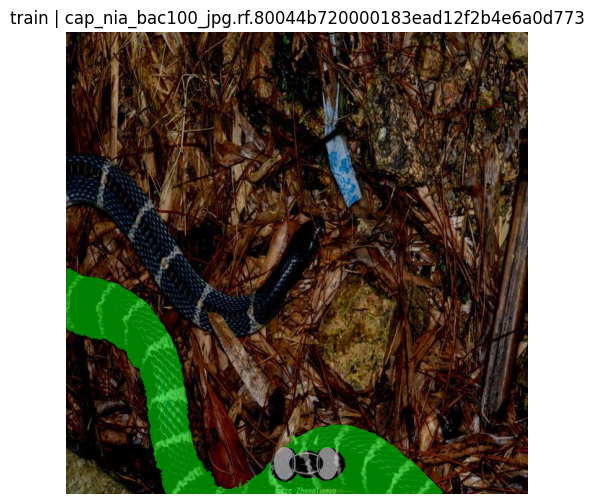

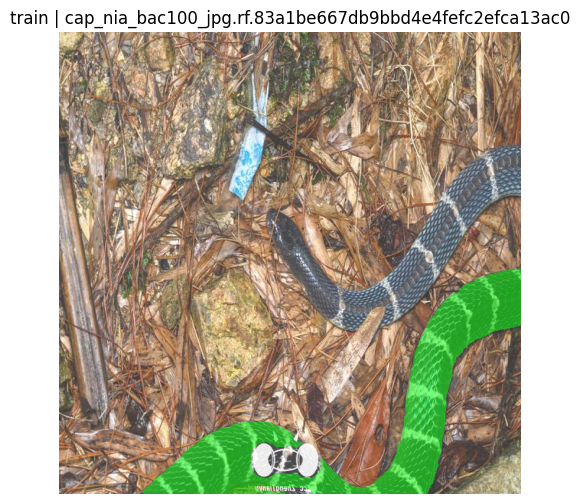

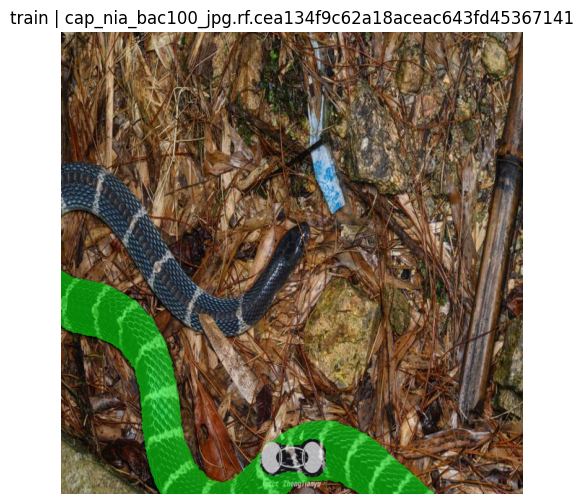

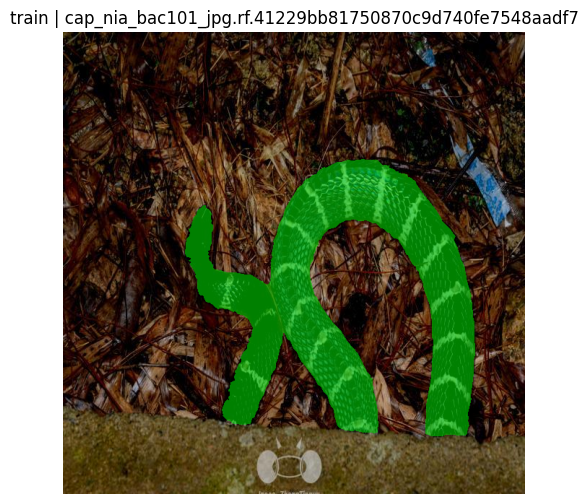

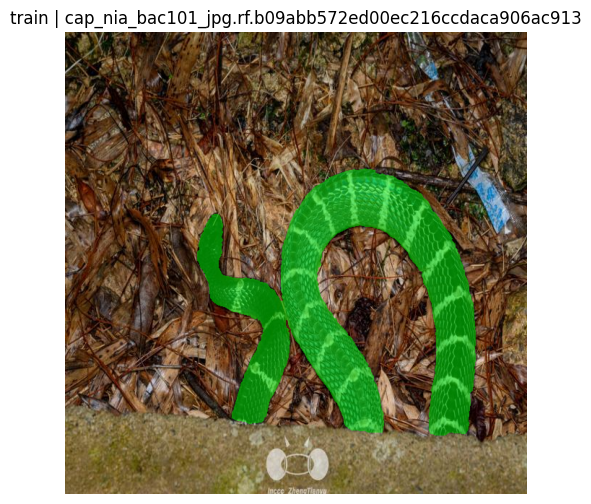


📂 Checking split: valid


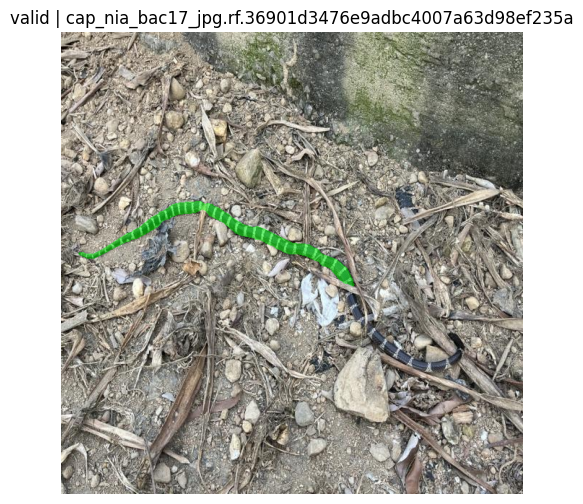

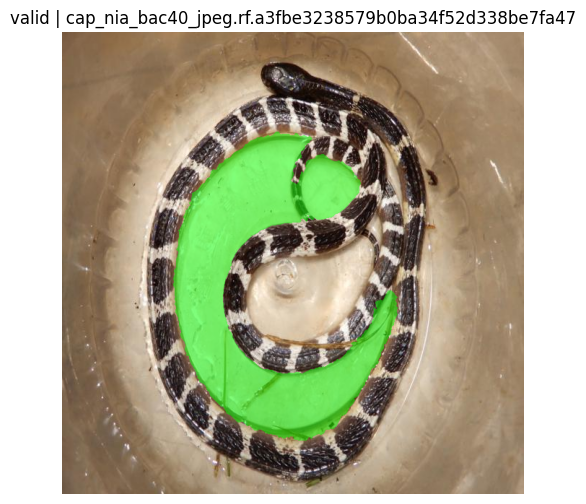

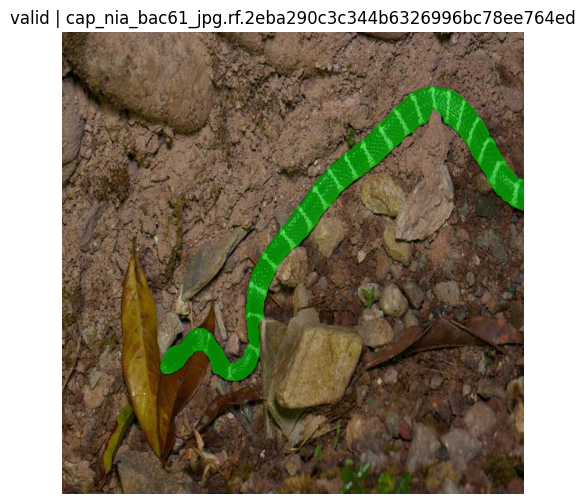

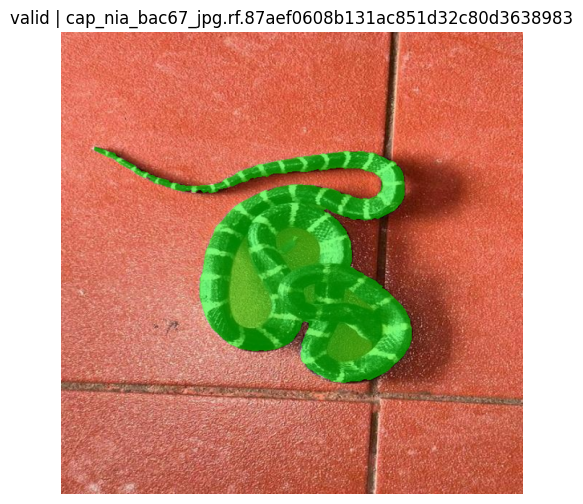

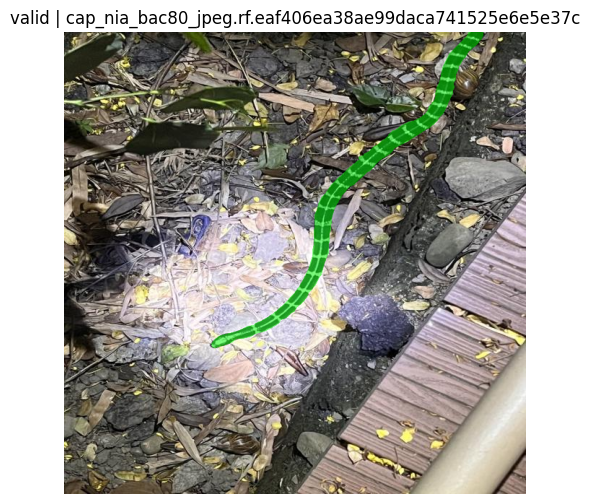


📂 Checking split: test


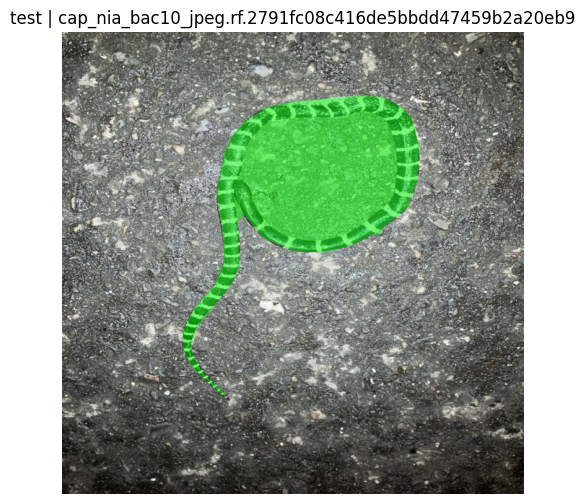

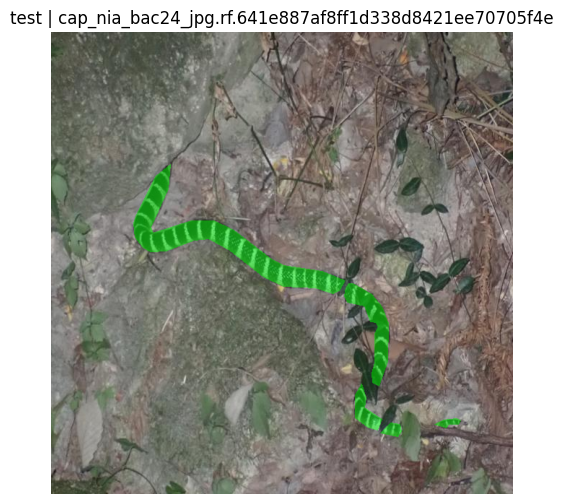

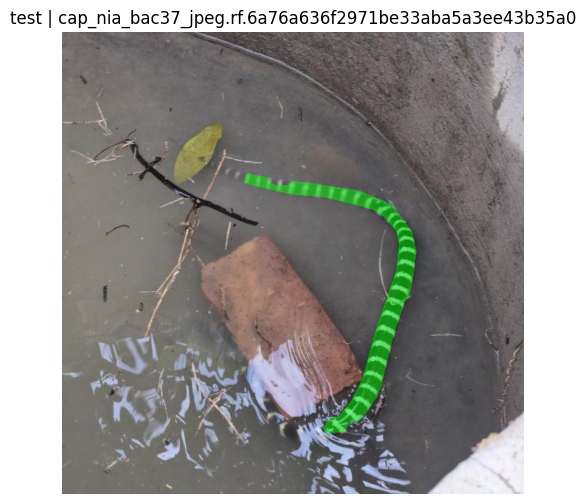

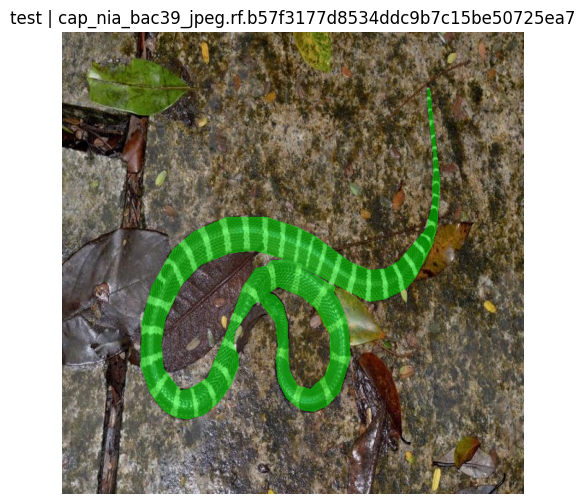

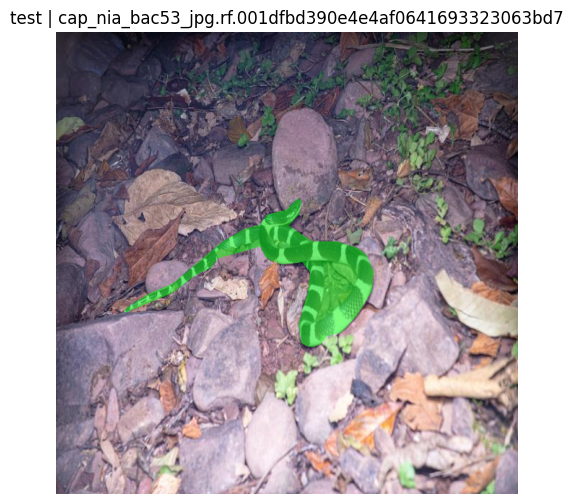

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CONFIG
# ==============================
DATASET_ROOT = "/content/drive/MyDrive/SnakeDataset/SnakeAid-YOLOv12-5000Masking"
SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = [".jpg", ".png", ".jpeg"]

SHOW_LIMIT = 5        # số ảnh hiển thị mỗi split
ALPHA = 0.5           # độ trong suốt mask

# ==============================
# UTILS
# ==============================
def find_image(image_dir, stem):
    for ext in IMAGE_EXTS:
        path = os.path.join(image_dir, stem + ext)
        if os.path.exists(path):
            return path
    return None


def load_yolo_segmentation(label_path, img_w, img_h):
    """
    Trả về list polygon (numpy array Nx2)
    """
    polygons = []

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue  # không đủ điểm polygon

            coords = list(map(float, parts[1:]))

            points = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * img_w)
                y = int(coords[i + 1] * img_h)
                points.append([x, y])

            polygons.append(np.array(points, dtype=np.int32))

    return polygons


def visualize_mask(img, polygons):
    overlay = img.copy()

    for poly in polygons:
        cv2.fillPoly(overlay, [poly], color=(0, 255, 0))

    return cv2.addWeighted(overlay, ALPHA, img, 1 - ALPHA, 0)


# ==============================
# MAIN
# ==============================
for split in SPLITS:
    print(f"\n📂 Checking split: {split}")

    img_dir = os.path.join(DATASET_ROOT, split, "images")
    lbl_dir = os.path.join(DATASET_ROOT, split, "labels")

    label_files = sorted([f for f in os.listdir(lbl_dir) if f.endswith(".txt")])

    shown = 0

    for lbl in label_files:
        stem = os.path.splitext(lbl)[0]

        img_path = find_image(img_dir, stem)
        lbl_path = os.path.join(lbl_dir, lbl)

        if img_path is None:
            print(f"❌ Missing image for label: {lbl}")
            continue

        img = cv2.imread(img_path)
        if img is None:
            print(f"❌ Cannot read image: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        polygons = load_yolo_segmentation(lbl_path, w, h)

        if len(polygons) == 0:
            print(f"⚠️ No mask found in: {lbl}")
            continue

        masked = visualize_mask(img, polygons)

        # ===== Show =====
        plt.figure(figsize=(6, 6))
        plt.imshow(masked)
        plt.title(f"{split} | {stem}")
        plt.axis("off")
        plt.show()

        shown += 1
        if shown >= SHOW_LIMIT:
            break


# Colab local masking verify

In [ ]:
import cv2
import numpy as np

In [ ]:
# --- Thay đường dẫn ảnh và file mask ---
img_path = "/content/ran_ho_mang_xiem_78_jpg.rf.a27e6baa5483e613774e15fba43403f7.jpg"
label_path = "/content/ran_ho_mang_xiem_78_jpg.rf.a27e6baa5483e613774e15fba43403f7.txt"

In [ ]:
# Load ảnh
img = cv2.imread(img_path)
h, w = img.shape[:2]

In [ ]:
# Load label
with open(label_path, "r") as f:
    data = f.read().strip().split()

# Bỏ class_id → lấy polygon points
coords = list(map(float, data[1:]))

In [ ]:
# Chuyển normalized → pixel
pts = []
for i in range(0, len(coords), 2):
    x = int(coords[i] * w)
    y = int(coords[i+1] * h)
    pts.append([x, y])

pts = np.array(pts, np.int32)

In [ ]:
# Vẽ polygon mask (đường viền + tô mờ)
vis = img.copy()
cv2.polylines(vis, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
cv2.fillPoly(vis, [pts], color=(0, 255, 0,))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")